# DS602 Final Project  
## Predicting Harmful Algae Bloom Risk in Maryland Waterways

This notebook collects water quality data from the Water Quality Portal API for Maryland from 2014–2024. The goal is to prepare a cleaned dataset that can be used in a separate modeling notebook to predict harmful algae bloom risk.

Chlorophyll-a is used as the bloom risk indicator. Samples with chlorophyll-a greater than 25 are labeled as high risk.

In [ ]:
# Import libraries used for data collection and preprocessing

import pandas as pd
import numpy as np
import requests
import os
import time
from io import StringIO
import matplotlib.pyplot as plt

## Create Project Folders

These folders keep the raw and processed data organized.

In [ ]:
# Create folders for raw and processed data

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

## Define API Parameters

The Water Quality Portal API is used to download Maryland water quality data from 2014–2024.  
The selected characteristics are related to algae bloom risk, including chlorophyll-a, nutrients, dissolved oxygen, pH, temperature, and turbidity.

In [ ]:
# Base URL for Water Quality Portal results API

BASE_URL = "https://www.waterqualitydata.us/data/Result/search"

# Basic API parameters
# US:24 = Maryland

base_params = {
    "countrycode": "US",
    "statecode": "US:24",
    "sampleMedia": "Water",
    "mimeType": "csv",
    "dataProfile": "narrowResult",
    "providers": "STORET"
}

# Water quality characteristics to download

characteristics = [
    "Chlorophyll a",
    "Phosphorus",
    "Nitrogen",
    "Nitrate",
    "Dissolved oxygen (DO)",
    "pH",
    "Temperature, water",
    "Turbidity"
]

# Years included in the study

years = range(2014, 2025)

## Download Data from API

The data is downloaded one characteristic and one year at a time. This avoids server errors that can happen when requesting too much data at once.

In [ ]:
# Download data one characteristic and one year at a time

all_dfs = []

for char in characteristics:
    for year in years:
        print(f"Downloading {char} for {year}...")

        params = base_params.copy()
        params["characteristicName"] = char
        params["startDateLo"] = f"01-01-{year}"
        params["startDateHi"] = f"12-31-{year}"

        try:
            response = requests.get(BASE_URL, params=params, timeout=120)

            if response.status_code == 200 and len(response.text) > 500:
                temp_df = pd.read_csv(StringIO(response.text), low_memory=False)

                # Add tracking columns so we know what was downloaded
                temp_df["downloaded_characteristic"] = char
                temp_df["download_year"] = year

                all_dfs.append(temp_df)

                print(f"Rows downloaded: {temp_df.shape[0]}")
            else:
                print("No usable data")

        except Exception as e:
            print(f"Failed for {char} {year}: {e}")

        # Pause briefly so we do not overload the API
        time.sleep(1)

print("Download loop finished.")

Rows downloaded: 7966
Rows downloaded: 8316
Rows downloaded: 7618
Rows downloaded: 5110
Rows downloaded: 4090
Rows downloaded: 4586
Rows downloaded: 2920
Rows downloaded: 4474
Rows downloaded: 4415
Rows downloaded: 3656
Rows downloaded: 4269
Rows downloaded: 4155
Rows downloaded: 4287
Rows downloaded: 3731
Rows downloaded: 3814
Rows downloaded: 163
Rows downloaded: 150
Rows downloaded: 67
Rows downloaded: 75
Rows downloaded: 81
Rows downloaded: 72
Rows downloaded: 59
Rows downloaded: 4147
Rows downloaded: 4411
Rows downloaded: 3997
Rows downloaded: 4029
Rows downloaded: 482
Rows downloaded: 329
Rows downloaded: 76
Rows downloaded: 87
Rows downloaded: 92
Rows downloaded: 88
Rows downloaded: 70
Rows downloaded: 4791
Rows downloaded: 5154
Rows downloaded: 4912
Rows downloaded: 1001
Rows downloaded: 4538
Rows downloaded: 4246
Rows downloaded: 3123
Rows downloaded: 4354
Rows downloaded: 4342
Rows downloaded: 4319
Rows downloaded: 4393
Rows downloaded: 37293
Rows downloaded: 37257
No usable 

## Combine Downloaded Data

All downloaded files are combined into one raw dataframe.

In [ ]:
# Combine all downloaded dataframes into one dataframe

wqp = pd.concat(all_dfs, ignore_index=True)

print("Raw combined dataset shape:", wqp.shape)

wqp.head()

Raw combined dataset shape: (862592, 80)


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,MonitoringLocationIdentifier,ResultIdentifier,DataLoggerLine,ResultDetectionConditionText,...,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,LaboratoryAccreditationIndicator,LaboratoryAccreditationAuthorityName,TaxonomistAccreditationIndicator,TaxonomistAccreditationAuthorityName,LabSamplePreparationUrl,ProviderName,downloaded_characteristic,download_year
0,CBP_WQX,Chesapeake Bay Program (CBP),CBP_WQX-412553_0.5_D_BS_WaterQ,2014-05-06,09:18:00,EST,CBP_WQX-XDJ6207,STORET-664618492,NaN,NaN,...,NaN,https://www.waterqualitydata.us/data/providers...,NaN,NaN,NaN,NaN,NaN,STORET,Chlorophyll a,2014
1,MDDNR,Maryland Department of Natural Resources,MDDNR-XHH3851\2014-11-10\1\2\S-PS1a,2014-11-10,NaN,NaN,MDDNR-XHH3851,STORET-891971295,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET,Chlorophyll a,2014
2,CBP_WQX,Chesapeake Bay Program (CBP),CBP_WQX-399919_0_D_S_WaterQ,2014-02-06,11:05:00,EST,CBP_WQX-POT1471,STORET-663993153,NaN,NaN,...,NaN,https://www.waterqualitydata.us/data/providers...,NaN,NaN,NaN,NaN,NaN,STORET,Chlorophyll a,2014
3,MDDNR,Maryland Department of Natural Resources,MDDNR-ANT0366\2014-09-16\0\1\S-PS1,2014-09-16,NaN,NaN,MDDNR-ANT0366,STORET-892022754,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STORET,Chlorophyll a,2014
4,CBP_WQX,Chesapeake Bay Program (CBP),CBP_WQX-398762_0.5_D_S_WaterQ,2014-12-18,11:25:00,EST,CBP_WQX-WT2.1,STORET-665192430,NaN,NaN,...,NaN,https://www.waterqualitydata.us/data/providers...,NaN,NaN,NaN,NaN,NaN,STORET,Chlorophyll a,2014


In [ ]:
# Save raw combined data

wqp.to_csv("data/raw/maryland_wqp_2014_2024_raw.csv", index=False)

print("Raw data saved.")

Raw data saved.


## Inspect Downloaded Characteristics

This shows how many observations were downloaded for each water quality measurement.

In [ ]:
# Count observations by characteristic

wqp["CharacteristicName"].value_counts()

,count
CharacteristicName,
"Temperature, water",390554
Dissolved oxygen (DO),157458
pH,144570
Chlorophyll a,57420
Nitrate,45173
Turbidity,32955
Nitrogen,17808
Phosphorus,16654


## Select Relevant Columns

The raw dataset has many columns. For modeling, we only need the site ID, date, measurement type, measurement value, and unit.

In [ ]:
# Keep only columns needed for preprocessing and modeling

wqp_small = wqp[
    [
        "MonitoringLocationIdentifier",
        "ActivityStartDate",
        "CharacteristicName",
        "ResultMeasureValue",
        "ResultMeasure/MeasureUnitCode"
    ]
].copy()

# Rename columns to simpler names

wqp_small = wqp_small.rename(columns={
    "MonitoringLocationIdentifier": "site_id",
    "ActivityStartDate": "date",
    "CharacteristicName": "characteristic",
    "ResultMeasureValue": "value",
    "ResultMeasure/MeasureUnitCode": "unit"
})

wqp_small.head()

,site_id,date,characteristic,value,unit
0,CBP_WQX-XDJ6207,2014-05-06,Chlorophyll a,15.308,ug/L
1,MDDNR-XHH3851,2014-11-10,Chlorophyll a,49.484,ug/L
2,CBP_WQX-POT1471,2014-02-06,Chlorophyll a,10.32,ug/L
3,MDDNR-ANT0366,2014-09-16,Chlorophyll a,2.0,ug/L
4,CBP_WQX-WT2.1,2014-12-18,Chlorophyll a,13.88,ug/L


## Clean Data Types

Dates are converted to datetime format, and measurement values are converted to numeric values.

In [ ]:
# Convert date column to datetime

wqp_small["date"] = pd.to_datetime(wqp_small["date"], errors="coerce")

# Convert measurement values to numeric

wqp_small["value"] = pd.to_numeric(wqp_small["value"], errors="coerce")

# Drop rows missing key information

wqp_small = wqp_small.dropna(subset=["site_id", "date", "characteristic", "value"])

print("Cleaned long-format shape:", wqp_small.shape)

wqp_small.head()

Cleaned long-format shape: (792256, 5)


,site_id,date,characteristic,value,unit
0,CBP_WQX-XDJ6207,2014-05-06,Chlorophyll a,15.308,ug/L
1,MDDNR-XHH3851,2014-11-10,Chlorophyll a,49.484,ug/L
2,CBP_WQX-POT1471,2014-02-06,Chlorophyll a,10.320,ug/L
3,MDDNR-ANT0366,2014-09-16,Chlorophyll a,2.000,ug/L
4,CBP_WQX-WT2.1,2014-12-18,Chlorophyll a,13.880,ug/L


## Reshape Data from Long to Wide Format

The API data is in long format, where each row is one measurement.  
For machine learning, the data is reshaped so each row represents one site-date observation, and each water quality characteristic becomes a separate column.

In [ ]:
# Pivot data so each characteristic becomes its own column

wqp_wide = wqp_small.pivot_table(
    index=["site_id", "date"],
    columns="characteristic",
    values="value",
    aggfunc="mean"
).reset_index()

print("Wide-format dataset shape:", wqp_wide.shape)

wqp_wide.head()

Wide-format dataset shape: (70246, 10)


characteristic,site_id,date,Chlorophyll a,Dissolved oxygen (DO),Nitrate,Nitrogen,Phosphorus,"Temperature, water",Turbidity,pH
0,11NPSWRD_WQX-CATO_WQ_CROW,2014-01-28,NaN,14.09,1.5,NaN,NaN,0.1,0.38,NaN
1,11NPSWRD_WQX-CATO_WQ_CROW,2014-03-18,NaN,11.83,1.5,NaN,NaN,5.8,0.46,NaN
2,11NPSWRD_WQX-CATO_WQ_CROW,2014-04-08,NaN,11.08,1.3,NaN,NaN,8.8,0.83,NaN
3,11NPSWRD_WQX-CATO_WQ_CROW,2014-05-21,NaN,9.88,1.3,NaN,NaN,13.8,4.05,NaN
4,11NPSWRD_WQX-CATO_WQ_CROW,2014-06-25,NaN,8.67,1.2,NaN,NaN,18.7,0.69,NaN


## Check Missing Values

Environmental datasets often have missing values because not every site measures every characteristic on every date.

In [ ]:
# Check missing values in wide-format dataset

wqp_wide.isnull().sum()

,0
characteristic,
site_id,0
date,0
Chlorophyll a,40087
Dissolved oxygen (DO),33561
Nitrate,48646
Nitrogen,62478
Phosphorus,63097
"Temperature, water",3623
Turbidity,50036


## Create Modeling Dataset

For the first version of the model, we use the variables with the best coverage:

- Chlorophyll-a
- Dissolved oxygen
- Water temperature
- pH

Chlorophyll-a is used to create the target variable, while the other variables are used as predictors.

In [ ]:
# Select variables for the modeling dataset

model_df = wqp_wide[
    [
        "site_id",
        "date",
        "Chlorophyll a",
        "Dissolved oxygen (DO)",
        "Temperature, water",
        "pH"
    ]
].copy()

print("Initial modeling dataset shape:", model_df.shape)

model_df.head()

Initial modeling dataset shape: (70246, 6)


characteristic,site_id,date,Chlorophyll a,Dissolved oxygen (DO),"Temperature, water",pH
0,11NPSWRD_WQX-CATO_WQ_CROW,2014-01-28,NaN,14.09,0.1,NaN
1,11NPSWRD_WQX-CATO_WQ_CROW,2014-03-18,NaN,11.83,5.8,NaN
2,11NPSWRD_WQX-CATO_WQ_CROW,2014-04-08,NaN,11.08,8.8,NaN
3,11NPSWRD_WQX-CATO_WQ_CROW,2014-05-21,NaN,9.88,13.8,NaN
4,11NPSWRD_WQX-CATO_WQ_CROW,2014-06-25,NaN,8.67,18.7,NaN


## Create Target Variable

A binary target variable is created using chlorophyll-a.

- 0 = Low bloom risk
- 1 = High bloom risk

A sample is labeled high risk if chlorophyll-a is greater than 25.

In [ ]:
# Create binary target variable

model_df["high_risk"] = (model_df["Chlorophyll a"] > 25).astype(int)

# Remove rows missing the target variable

model_df = model_df.dropna(subset=["Chlorophyll a"])

print("Dataset shape after removing missing target values:", model_df.shape)

model_df["high_risk"].value_counts()

Dataset shape after removing missing target values: (30159, 7)


,count
high_risk,
0,25474
1,4685


## Handle Missing Feature Values

Missing numerical feature values are filled using the median. Median imputation is used because it is less affected by extreme values than the mean.

In [ ]:
# Fill missing numeric values using median imputation

model_df = model_df.fillna(model_df.median(numeric_only=True))

# Confirm missing values are handled

model_df.isnull().sum()

,0
characteristic,
site_id,0
date,0
Chlorophyll a,0
Dissolved oxygen (DO),0
"Temperature, water",0
pH,0
high_risk,0


## Final Cleaned Dataset Preview

This is the final dataset that will be used in the modeling notebook.

Note: Nitrogen and phosphorus were downloaded but not included in the final model because they had substantial missing values across site-date observations. To reduce excessive imputation and preserve sample size, the final model used variables with stronger coverage.

In [ ]:
# View final cleaned modeling dataset

print("Final cleaned dataset shape:", model_df.shape)

model_df.head()

Final cleaned dataset shape: (30159, 7)


characteristic,site_id,date,Chlorophyll a,Dissolved oxygen (DO),"Temperature, water",pH,high_risk
908,21DELAWQ_WQX-304011,2014-02-10,1.99,12.94,2.60,7.711111,0
909,21DELAWQ_WQX-304011,2014-04-16,14.90,9.26,14.27,7.711111,0
910,21DELAWQ_WQX-304011,2014-06-23,52.00,9.80,26.73,7.711111,1
911,21DELAWQ_WQX-304011,2014-07-21,127.00,9.44,26.09,7.711111,1
912,21DELAWQ_WQX-304011,2014-08-25,58.50,9.06,24.95,7.711111,1


## Class Balance

This chart shows how many observations are low risk versus high risk.

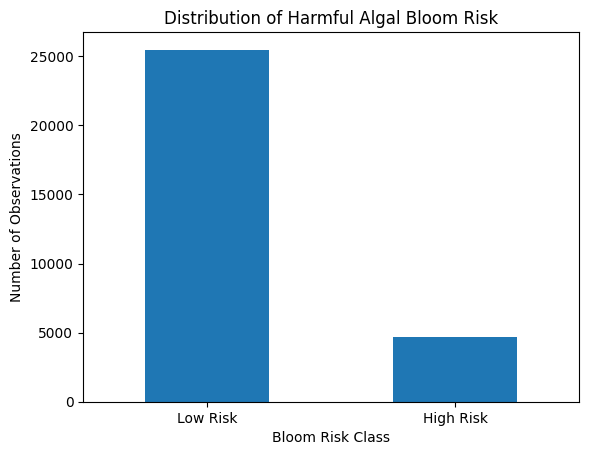

In [ ]:
# Plot distribution of target variable

model_df["high_risk"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Harmful Algal Bloom Risk")
plt.xlabel("Bloom Risk Class")
plt.ylabel("Number of Observations")
plt.xticks(
    ticks=[0, 1],
    labels=["Low Risk", "High Risk"],
    rotation=0
)

plt.show()

## Save Cleaned Dataset

The cleaned dataset is saved so it can be loaded directly into the modeling and evaluation notebook.

In [ ]:
# Save cleaned dataset for modeling notebook

model_df.to_csv("data/processed/cleaned_model_data.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Final dataset shape:", model_df.shape)

Cleaned dataset saved successfully.
Final dataset shape: (30159, 7)


In [ ]:
# Quick statistical summary of modeling features

model_df.describe()

characteristic,date,Chlorophyll a,Dissolved oxygen (DO),"Temperature, water",pH,high_risk
count,30159,30159.000000,30159.000000,30159.000000,30159.000000,30159.000000
mean,2018-08-20 13:38:34.413608192,15.679511,8.642035,17.013133,7.700094,0.155343
min,2014-01-06 00:00:00,-0.270000,0.100000,-0.300000,3.430000,0.000000
25%,2015-09-15 00:00:00,2.850000,8.070714,10.380556,7.650000,0.000000
50%,2017-11-13 00:00:00,7.262500,8.542857,18.000000,7.711111,0.000000
75%,2021-08-03 00:00:00,16.072500,9.100000,24.000000,7.800000,0.000000
max,2024-12-16 00:00:00,1262.909975,18.750000,34.700000,10.200000,1.000000
std,NaN,29.763709,2.079981,8.049390,0.370047,0.362238


## Preprocessing Complete

The data collection and preprocessing steps are complete.

Key steps completed in this notebook:

- Collected Maryland water quality data from the Water Quality Portal API
- Downloaded data from 2014–2024
- Combined multiple water quality characteristics
- Cleaned dates and measurement values
- Reshaped the data from long format to wide format
- Created a binary harmful algal bloom risk target variable
- Filled missing feature values using median imputation
- Saved the final cleaned dataset for modeling

The next notebook will use the cleaned dataset to train, tune, compare, and evaluate machine learning models.